MODELO PRINCIPAL PARA SIMULACION DE ESCENARIOS CRITICOS

In [ ]:
import pandas as pd

df = pd.read_excel("Base_de_datos_CA.xlsx")

df.head()

,ID_PISCINA,TAN,NH3T,NO2,NO3,PO4,SULFURO,ALK,PH,TEMP,SALINIDAD,R_NP,N_ENF,NRS
0,CA_001,0.08,0.000,0.043,1.577,0.25,0.05,145.0,6.84,26.9,33.0,5.299515,3.0,MEDIO
1,CA_002,0.02,0.001,0.036,2.104,0.96,0.03,165.0,7.80,28.0,30.0,1.610227,3.0,MEDIO
2,CA_003,0.05,0.000,0.700,1.750,0.84,0.03,130.0,7.06,27.8,30.0,2.348485,3.0,ALTO
3,CA_004,0.17,0.009,0.066,0.957,0.36,0.07,360.0,8.10,21.6,6.0,3.121296,3.0,MEDIO
4,CA_005,0.27,0.011,0.046,0.930,0.28,0.05,320.0,7.67,21.5,6.0,4.714286,3.0,MEDIO


In [ ]:
# Variable objetivo
y = df["NRS"]

# Variables de entrada
X = df.drop(columns=["ID_PISCINA", "NRS", "N_ENF"])

In [ ]:
print(X.isnull().sum())
print(df["NRS"].value_counts())

TAN           0
NH3T          0
NO2           0
NO3           1
PO4           0
SULFURO      63
ALK          10
PH            0
TEMP          0
SALINIDAD     0
R_NP          0
dtype: int64
NRS
BAJO     59
MEDIO    54
ALTO     40
Name: count, dtype: int64


In [ ]:
# Rellenar valores faltantes con la media
X["SULFURO"].fillna(X["SULFURO"].mean(), inplace=True)
X["ALK"].fillna(X["ALK"].mean(), inplace=True)
X["NO3"].fillna(X["NO3"].mean(), inplace=True)

/tmp/ipykernel_23751/545327332.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X["SULFURO"].fillna(X["SULFURO"].mean(), inplace=True)
/tmp/ipykernel_23751/545327332.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (122, 11)
Test: (31, 11)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

modelo_rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
y_pred = modelo_rf.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8387096774193549

Classification Report:

              precision    recall  f1-score   support

        ALTO       0.88      0.88      0.88         8
        BAJO       1.00      0.75      0.86        12
       MEDIO       0.71      0.91      0.80        11

    accuracy                           0.84        31
   macro avg       0.86      0.84      0.84        31
weighted avg       0.87      0.84      0.84        31


Confusion Matrix:

[[ 7  0  1]
 [ 0  9  3]
 [ 1  0 10]]


SIMULACION DE ESCENARIOS

1. DATOS RUIDOSOS / INCOMPLETOS

In [ ]:
import numpy as np
import pandas as pd

from sklearn.metrics import accuracy_score, classification_report, recall_score

In [ ]:
y_pred_base = modelo_rf.predict(X_test)

acc_base = accuracy_score(y_test, y_pred_base)

print("=== BASELINE ===")
print("Accuracy:", acc_base)
print(classification_report(y_test, y_pred_base))

=== BASELINE ===
Accuracy: 0.8387096774193549
              precision    recall  f1-score   support

        ALTO       0.88      0.88      0.88         8
        BAJO       1.00      0.75      0.86        12
       MEDIO       0.71      0.91      0.80        11

    accuracy                           0.84        31
   macro avg       0.86      0.84      0.84        31
weighted avg       0.87      0.84      0.84        31



In [ ]:
# Ruido gaussiano
X_ruido = X_test.copy()
X_ruido = X_ruido + np.random.normal(0, 0.05, X_ruido.shape)

y_pred_ruido = modelo_rf.predict(X_ruido)

acc_ruido = accuracy_score(y_test, y_pred_ruido)

print("=== RUIDO ===")
print("Accuracy:", acc_ruido)
print(classification_report(y_test, y_pred_ruido))
print("Δ Accuracy (ruido vs baseline):", acc_ruido - acc_base)

recall_base = recall_score(y_test, y_pred_base, average=None)
recall_ruido = recall_score(y_test, y_pred_ruido, average=None)

print("Recall base:", recall_base)
print("Recall ruido:", recall_ruido)

=== RUIDO ===
Accuracy: 0.8064516129032258
              precision    recall  f1-score   support

        ALTO       0.78      0.88      0.82         8
        BAJO       0.91      0.83      0.87        12
       MEDIO       0.73      0.73      0.73        11

    accuracy                           0.81        31
   macro avg       0.80      0.81      0.81        31
weighted avg       0.81      0.81      0.81        31

Δ Accuracy (ruido vs baseline): -0.032258064516129115
Recall base: [0.875      0.75       0.90909091]
Recall ruido: [0.875      0.83333333 0.72727273]


In [ ]:
# Missing values
X_missing = X_test.copy()
mask = np.random.rand(*X_missing.shape) < 0.1
X_missing[mask] = np.nan

# Imputación simple
X_missing = X_missing.fillna(X_missing.mean())

y_pred_missing = modelo_rf.predict(X_missing)

acc_missing = accuracy_score(y_test, y_pred_missing)

print("=== MISSING ===")
print("Accuracy:", acc_missing)
print(classification_report(y_test, y_pred_missing))
print("Δ Accuracy (missing vs baseline):", acc_missing - acc_base)

recall_missing = recall_score(y_test, y_pred_missing, average=None)

print("Recall base:", recall_base)
print("Recall missing:", recall_missing)

=== MISSING ===
Accuracy: 0.8064516129032258
              precision    recall  f1-score   support

        ALTO       0.86      0.75      0.80         8
        BAJO       0.82      0.75      0.78        12
       MEDIO       0.77      0.91      0.83        11

    accuracy                           0.81        31
   macro avg       0.81      0.80      0.81        31
weighted avg       0.81      0.81      0.81        31

Δ Accuracy (missing vs baseline): -0.032258064516129115
Recall base: [0.875      0.75       0.90909091]
Recall missing: [0.75       0.75       0.90909091]


In [ ]:
# Outliers
X_outliers = X_test.copy()
X_outliers = X_outliers * np.random.uniform(1.5, 2.0)

y_pred_outliers = modelo_rf.predict(X_outliers)

acc_outliers = accuracy_score(y_test, y_pred_outliers)

print("=== OUTLIERS ===")
print("Accuracy:", acc_outliers)
print(classification_report(y_test, y_pred_outliers))
print("Δ Accuracy (outliers vs baseline):", acc_outliers - acc_base)

recall_outliers = recall_score(y_test, y_pred_outliers, average=None)

print("Recall base:", recall_base)
print("Recall outliers:", recall_outliers)

=== OUTLIERS ===
Accuracy: 0.3548387096774194
              precision    recall  f1-score   support

        ALTO       0.35      0.88      0.50         8
        BAJO       0.57      0.33      0.42        12
       MEDIO       0.00      0.00      0.00        11

    accuracy                           0.35        31
   macro avg       0.31      0.40      0.31        31
weighted avg       0.31      0.35      0.29        31

Δ Accuracy (outliers vs baseline): -0.4838709677419355
Recall base: [0.875      0.75       0.90909091]
Recall outliers: [0.875      0.33333333 0.        ]


In [ ]:
resultados_ruido = pd.DataFrame({
    "Escenario": ["Baseline", "Ruido Gaussiano", "Missing Values", "Outliers"],
    "Accuracy": [acc_base, acc_ruido, acc_missing, acc_outliers]
})

print(resultados_ruido)

         Escenario  Accuracy
0         Baseline  0.838710
1  Ruido Gaussiano  0.806452
2   Missing Values  0.806452
3         Outliers  0.354839


2. DATA DRIFT

In [ ]:
# Data drift
X_drift = X_test.copy()
X_drift["TEMP"] = X_drift["TEMP"] + 3
X_drift["SALINIDAD"] = X_drift["SALINIDAD"] - 5
X_drift["TAN"] = X_drift["TAN"] * 1.3

y_pred_drift = modelo_rf.predict(X_drift)

acc_drift = accuracy_score(y_test, y_pred_drift)

print("=== DATA DRIFT ===")
print("Accuracy:", acc_drift)
print(classification_report(y_test, y_pred_drift))
print("Δ Accuracy (drift vs baseline):", acc_drift - acc_base)

recall_drift = recall_score(y_test, y_pred_drift, average=None)

print("Recall base:", recall_base)
print("Recall drift:", recall_drift)

=== DATA DRIFT ===
Accuracy: 0.7096774193548387
              precision    recall  f1-score   support

        ALTO       0.78      0.88      0.82         8
        BAJO       0.80      0.67      0.73        12
       MEDIO       0.58      0.64      0.61        11

    accuracy                           0.71        31
   macro avg       0.72      0.73      0.72        31
weighted avg       0.72      0.71      0.71        31

Δ Accuracy (drift vs baseline): -0.12903225806451613
Recall base: [0.875      0.75       0.90909091]
Recall drift: [0.875      0.66666667 0.63636364]


3. PRUEBAS DE ESTRÉS

In [ ]:
# Inputs extremos
X_extremo = X_test.copy()
X_extremo["NH3T"] = 5
X_extremo["PO4"] = 5
X_extremo["TAN"] = 5

y_pred_extremo = modelo_rf.predict(X_extremo)

acc_extremo = accuracy_score(y_test, y_pred_extremo)

print("=== INPUTS EXTREMOS ===")
print("Accuracy:", acc_extremo)
print(classification_report(y_test, y_pred_extremo))
print("Δ Accuracy (extremos vs baseline):", acc_extremo - acc_base)

recall_extremo = recall_score(y_test, y_pred_extremo, average=None)

print("Recall base:", recall_base)
print("Recall extremos:", recall_extremo)

=== INPUTS EXTREMOS ===
Accuracy: 0.25806451612903225
              precision    recall  f1-score   support

        ALTO       0.26      1.00      0.41         8
        BAJO       0.00      0.00      0.00        12
       MEDIO       0.00      0.00      0.00        11

    accuracy                           0.26        31
   macro avg       0.09      0.33      0.14        31
weighted avg       0.07      0.26      0.11        31

Δ Accuracy (extremos vs baseline): -0.5806451612903226
Recall base: [0.875      0.75       0.90909091]
Recall extremos: [1. 0. 0.]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Volumen de datos
X_grande = pd.concat([X_test] * 50, ignore_index=True)

y_pred_grande = modelo_rf.predict(X_grande)

print("=== VOLUMEN ===")
print("Número de registros procesados:", len(X_grande))
print("Número de predicciones generadas:", len(y_pred_grande))

=== VOLUMEN ===
Número de registros procesados: 1550
Número de predicciones generadas: 1550


RESUMEN

In [ ]:
resultados_finales = pd.DataFrame({
    "Escenario": [
        "Baseline",
        "Ruido Gaussiano",
        "Missing Values",
        "Outliers",
        "Data Drift",
        "Inputs Extremos"
    ],
    "Accuracy": [
        acc_base,
        acc_ruido,
        acc_missing,
        acc_outliers,
        acc_drift,
        acc_extremo
    ]
})

print(resultados_finales)

         Escenario  Accuracy
0         Baseline  0.838710
1  Ruido Gaussiano  0.806452
2   Missing Values  0.806452
3         Outliers  0.354839
4       Data Drift  0.709677
5  Inputs Extremos  0.258065


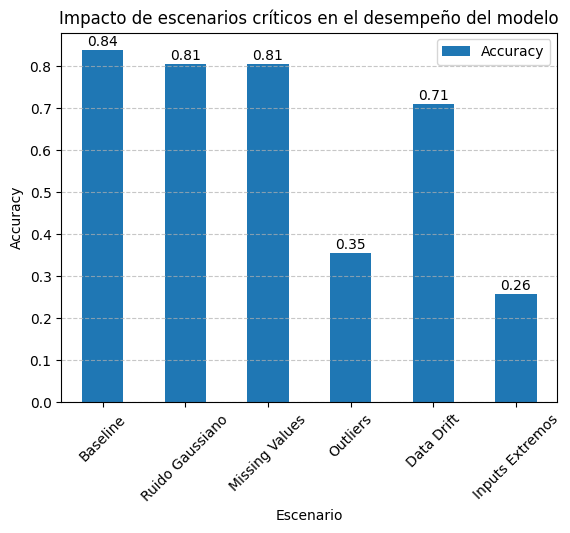

In [ ]:
import matplotlib.pyplot as plt

ax = resultados_finales.plot(x="Escenario", y="Accuracy", kind="bar")

plt.title("Impacto de escenarios críticos en el desempeño del modelo")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)

for i, v in enumerate(resultados_finales["Accuracy"]):
    ax.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()